## PROJET DE DATA SCIENCE

### Importation des packages nécéssaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("✅ Packages importés avec succès !")
print(f"Pandas version : {pd.__version__}")
print(f"Numpy version  : {np.__version__}")

✅ Packages importés avec succès !
Pandas version : 3.0.2
Numpy version  : 2.4.4


### CHARGEMENT DU DATASET

In [2]:
import pandas as pd

# Chargement du dataset
df = pd.read_csv('../data/creditcard.csv')

# Premières lignes
print("=== Premières lignes ===")
display(df.head())

# Forme du dataset
print(f"\n=== Forme du dataset ===")
print(f"Lignes : {df.shape[0]:,}  |  Colonnes : {df.shape[1]}")

# Informations générales
print("\n=== Informations générales ===")
df.info()


=== Premières lignes ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



=== Forme du dataset ===
Lignes : 284,807  |  Colonnes : 31

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19 

### Analyse du déséquilibre des classes

=== Distribution des classes ===
Transactions normales (0) : 284,315  (99.827%)
Transactions frauduleuses (1) : 492  (0.173%)


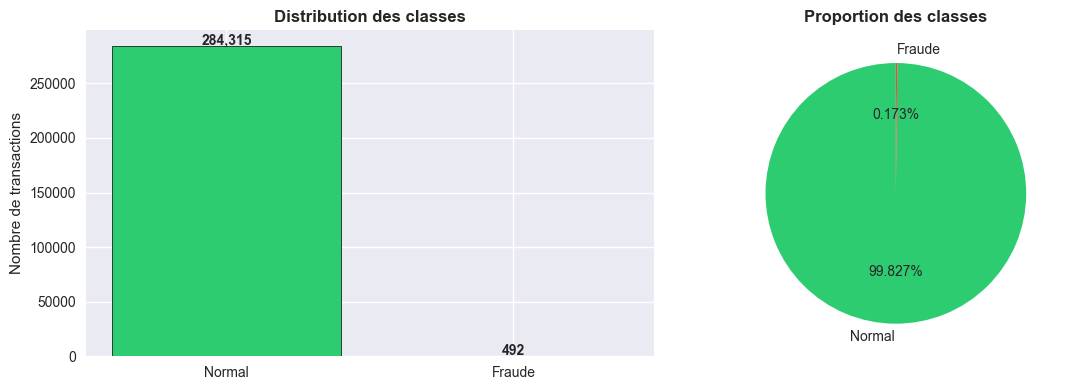

In [3]:
# Distribution des classes
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=== Distribution des classes ===")
print(f"Transactions normales (0) : {class_counts[0]:,}  ({class_pct[0]:.3f}%)")
print(f"Transactions frauduleuses (1) : {class_counts[1]:,}  ({class_pct[1]:.3f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 — Barplot
axes[0].bar(['Normal', 'Fraude'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Graphique 2 — Pie chart
axes[1].pie(class_counts.values,
            labels=['Normal', 'Fraude'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.tight_layout()
plt.show()

### ANALYSE DU MONTANT DES TRANSACTIONS

=== Montant des transactions normales ===
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

=== Montant des transactions frauduleuses ===
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


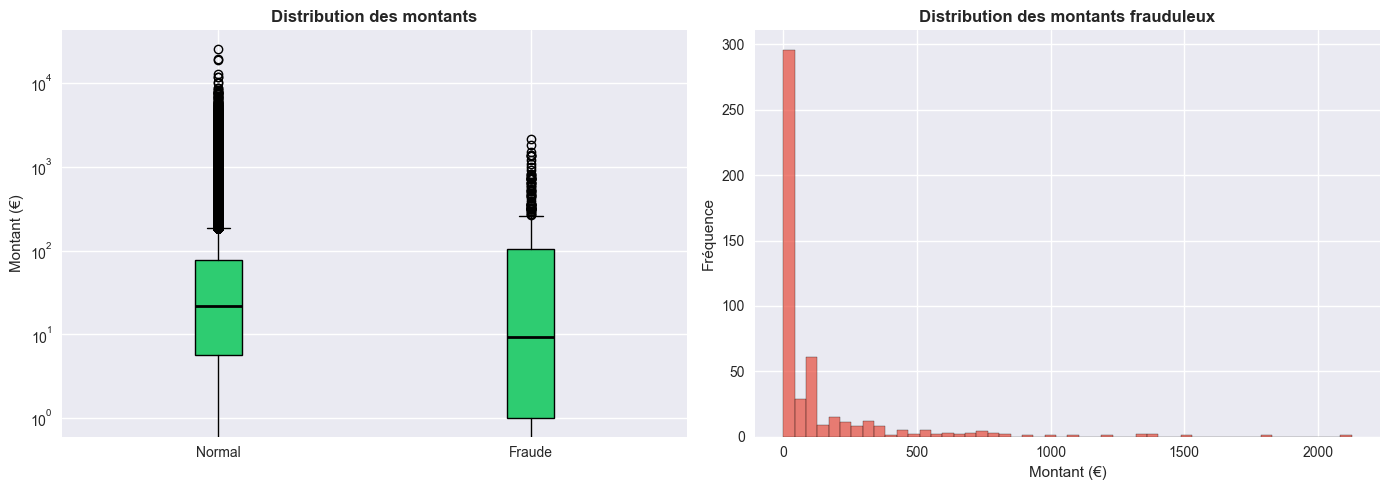

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Montant par classe
normal = df[df['Class'] == 0]['Amount']
fraude = df[df['Class'] == 1]['Amount']

# Statistiques
print("=== Montant des transactions normales ===")
print(normal.describe().round(2))
print("\n=== Montant des transactions frauduleuses ===")
print(fraude.describe().round(2))

# Graphique 1 — Boxplot
axes[0].boxplot([normal, fraude], labels=['Normal', 'Fraude'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Distribution des montants', fontweight='bold')
axes[0].set_ylabel('Montant (€)')
axes[0].set_yscale('log')

# Graphique 2 — Histogramme
axes[1].hist(fraude, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].set_title('Distribution des montants frauduleux', fontweight='bold')
axes[1].set_xlabel('Montant (€)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

### ANALYSE TEMPORELLE

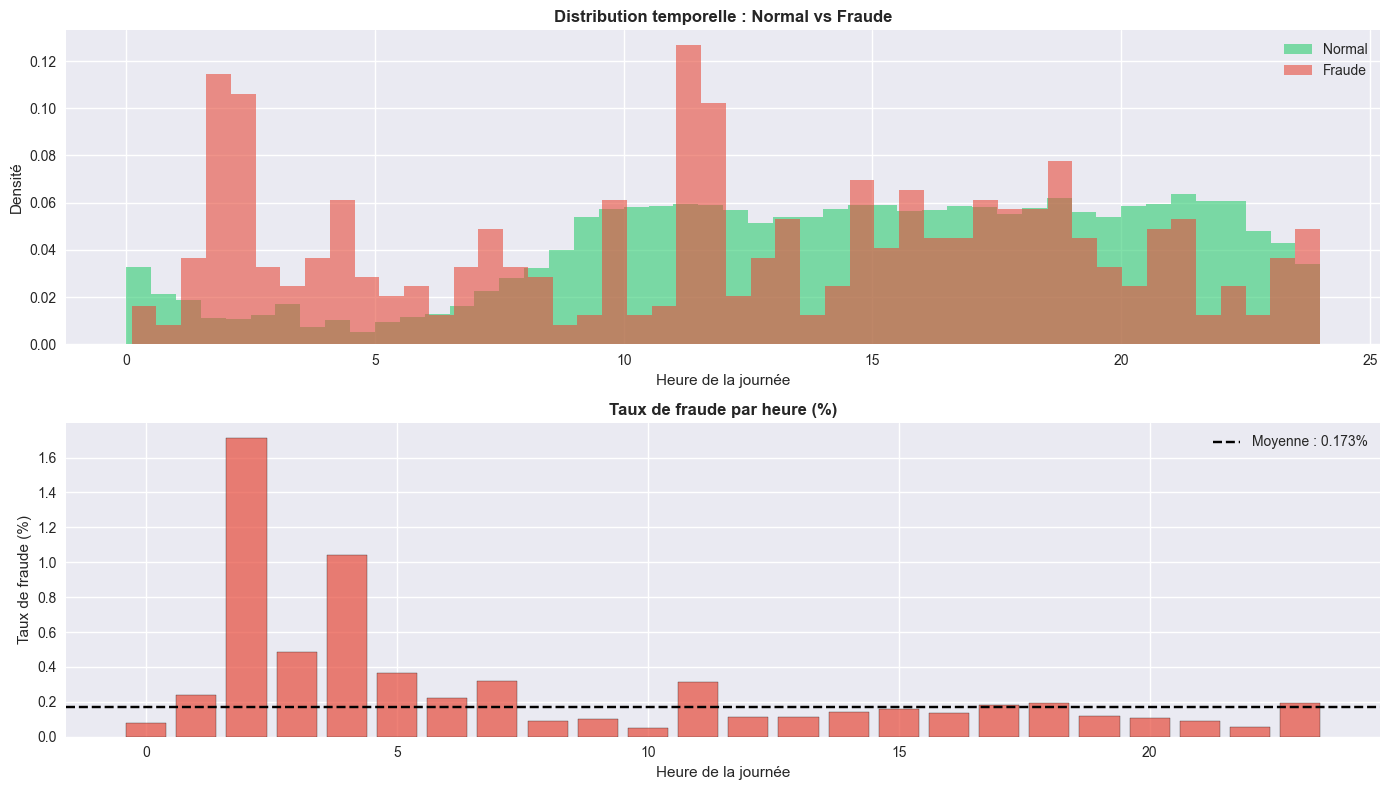


Heure avec le plus de fraudes : 2h
Taux de fraude max : 1.713%


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Conversion du temps en heures
df['Hour'] = (df['Time'] / 3600) % 24

normal_h = df[df['Class'] == 0]['Hour']
fraude_h = df[df['Class'] == 1]['Hour']

# Graphique 1 — Distribution temporelle normale vs fraude
axes[0].hist(normal_h, bins=48, color='#2ecc71', alpha=0.6, label='Normal', density=True)
axes[0].hist(fraude_h, bins=48, color='#e74c3c', alpha=0.6, label='Fraude', density=True)
axes[0].set_title('Distribution temporelle : Normal vs Fraude', fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Densité')
axes[0].legend()

# Graphique 2 — Taux de fraude par heure
fraude_rate = df.groupby(df['Hour'].astype(int))['Class'].mean() * 100
axes[1].bar(fraude_rate.index, fraude_rate.values, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].set_title('Taux de fraude par heure (%)', fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Taux de fraude (%)')
axes[1].axhline(y=df['Class'].mean()*100, color='black', linestyle='--', label=f'Moyenne : {df["Class"].mean()*100:.3f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nHeure avec le plus de fraudes : {fraude_rate.idxmax()}h")
print(f"Taux de fraude max : {fraude_rate.max():.3f}%")

### Corrélation des variables avec la fraude

=== Top 10 variables les plus corrélées à la FRAUDE ===

Corrélations NÉGATIVES (fraude = valeurs basses) :
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V18   -0.1115
V1    -0.1013
V9    -0.0977
Name: Class, dtype: float64

Corrélations POSITIVES (fraude = valeurs hautes) :
Amount    0.0056
V28       0.0095
V27       0.0176
V8        0.0199
V20       0.0201
V19       0.0348
V21       0.0404
V2        0.0913
V4        0.1334
V11       0.1549
Name: Class, dtype: float64


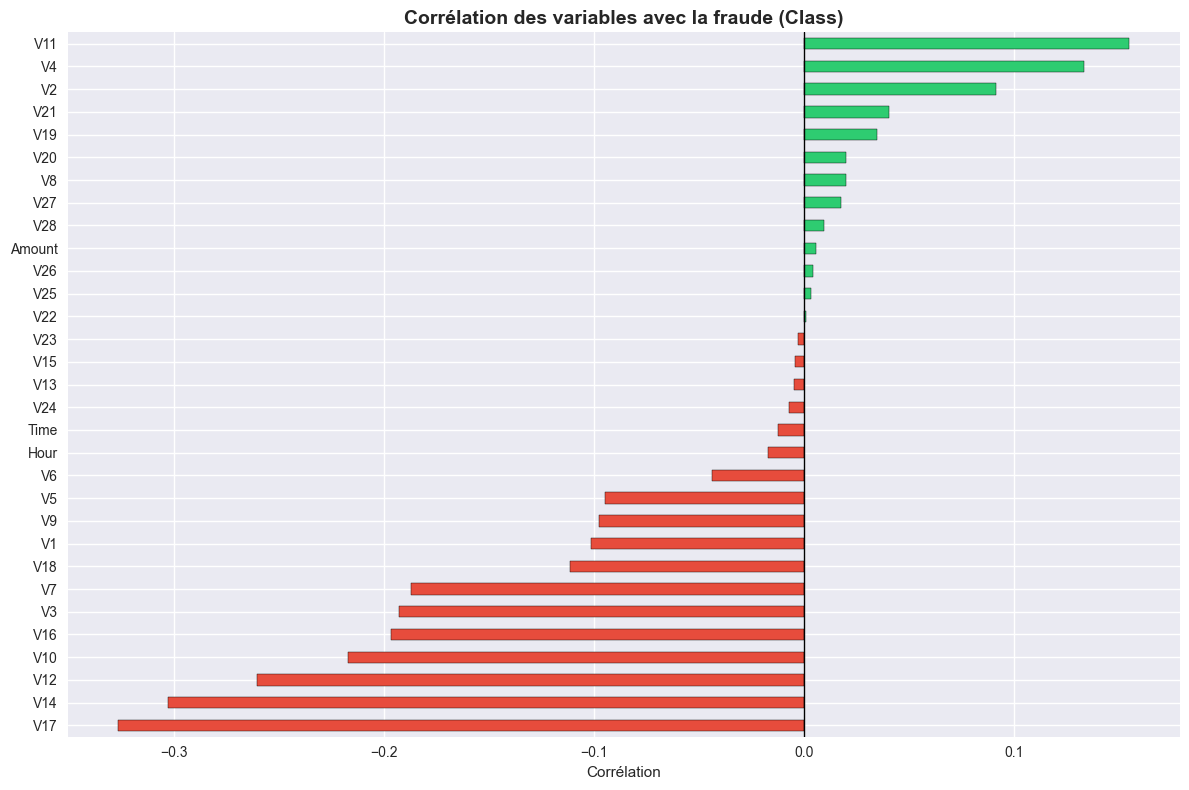

In [6]:
# 1. Corrélation de chaque variable avec la Class
correlations = df.corr()['Class'].drop('Class').sort_values()

print("=== Top 10 variables les plus corrélées à la FRAUDE ===")
print("\nCorrélations NÉGATIVES (fraude = valeurs basses) :")
print(correlations.head(10).round(4))
print("\nCorrélations POSITIVES (fraude = valeurs hautes) :")
print(correlations.tail(10).round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Corrélation des variables avec la fraude (Class)', fontweight='bold', fontsize=14)
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.show()

Variables les plus importantes pour détecter les fraudes :
🔴 Corrélations négatives (quand ces valeurs sont basses → fraude probable)

V17 (-0.33), V14 (-0.30), V12 (-0.26), V10 (-0.22) → ce sont les signaux d'alerte les plus forts

🟢 Corrélations positives (quand ces valeurs sont hautes → fraude probable)

V11 (0.15), V4 (0.13), V2 (0.09) → signaux secondaires

À noter 👉 Amount a une corrélation quasi nulle (0.006) — le montant seul ne suffit pas à détecter une fraude !

### DISTRIBUTION DES VARIABLES CLÉS

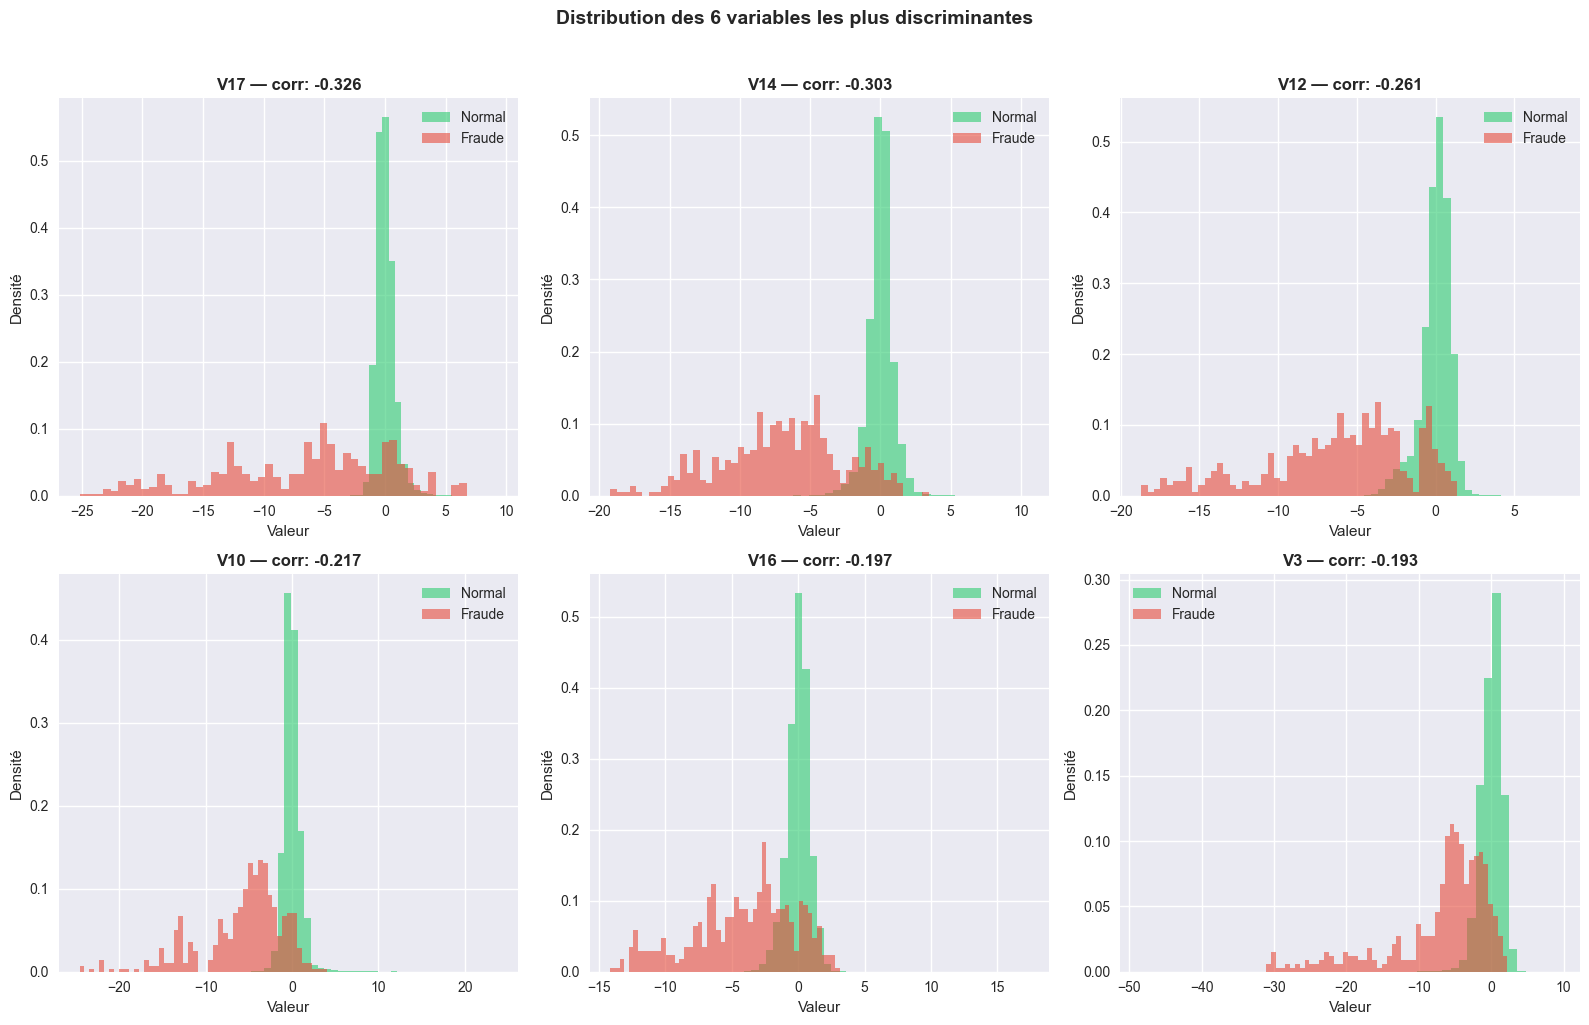

In [7]:
# Variables les plus corrélées (top 6)
top_vars = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    normal_vals = df[df['Class'] == 0][var]
    fraude_vals = df[df['Class'] == 1][var]
    
    axes[i].hist(normal_vals, bins=50, alpha=0.6, color='#2ecc71', 
                 label='Normal', density=True)
    axes[i].hist(fraude_vals, bins=50, alpha=0.6, color='#e74c3c', 
                 label='Fraude', density=True)
    axes[i].set_title(f'{var} — corr: {correlations[var]:.3f}', fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des 6 variables les plus discriminantes', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Ce qu'on voit clairement :

🟢 Transactions normales → toutes concentrées autour de 0 (distribution étroite)
🔴 Fraudes → distribution étalée vers les valeurs négatives (-25 à -5)

C'est exactement ce que la corrélation nous disait — quand V17, V14, V12 prennent des valeurs très négatives, c'est un signal fort de fraude. Le modèle XGBoost va adorer ces variables !

### HEATMAP DE CORRÉLATION

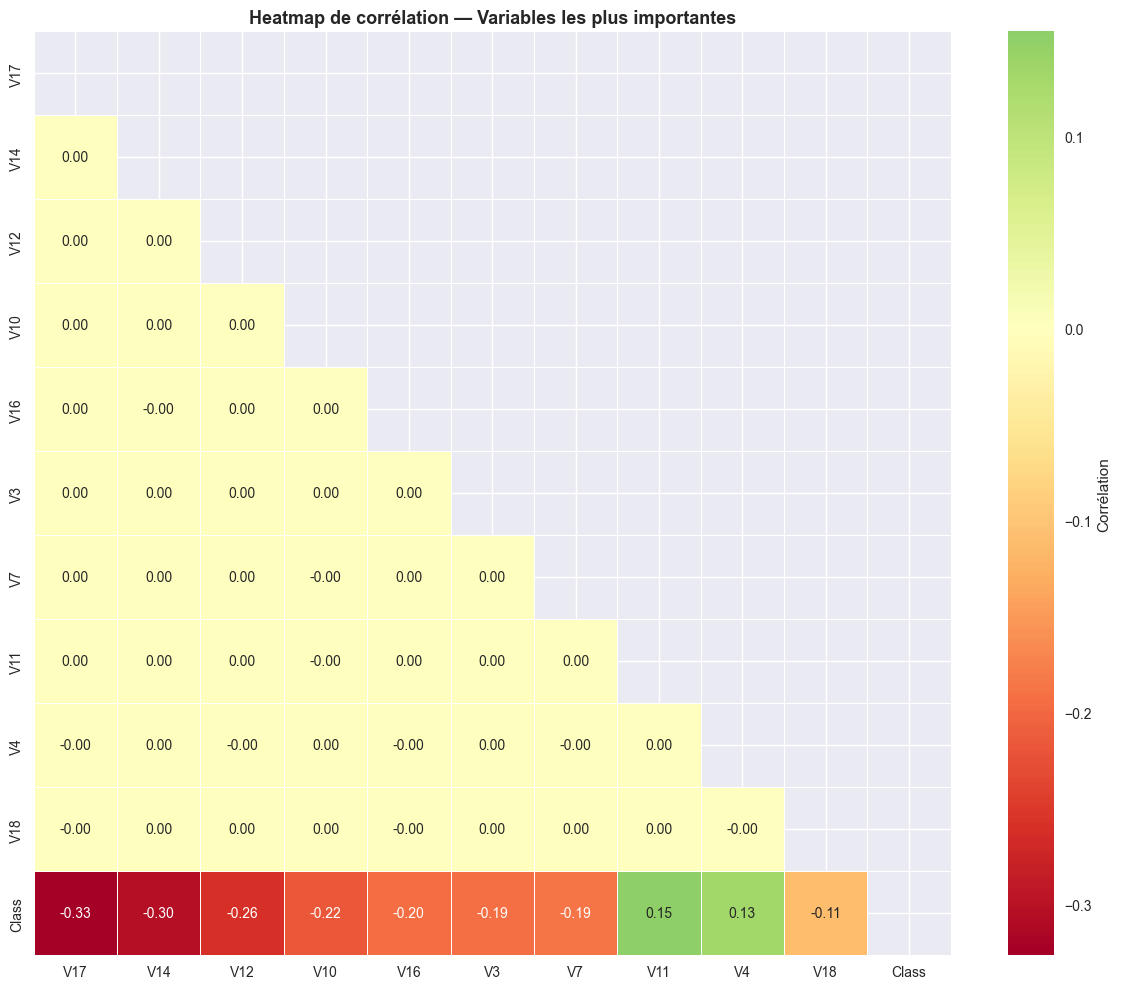

In [8]:
# On prend les variables les plus corrélées + Class
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('Class')

plt.figure(figsize=(12, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Corrélation'})

plt.title('Heatmap de corrélation — Variables les plus importantes', 
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Observation très importante 👇

Les variables V17, V14, V12, V10... ont toutes une corrélation quasi nulle entre elles (0.00 partout)
Mais elles sont toutes fortement corrélées à Class
C'est parfait ! Pas de multicolinéarité → chaque variable apporte une information unique au modèle

### REPROCESSING + SMOTE

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Normalisation de Amount et Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# 2. Features et target
X = df.drop(['Class', 'Amount', 'Time', 'Hour'], axis=1)
y = df['Class']

print(f"Features utilisées : {X.shape[1]} colonnes")
print(f"Colonnes : {list(X.columns)}")

# 3. Split train/test AVANT SMOTE (très important !)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== Split Train/Test ===")
print(f"Train : {X_train.shape[0]:,} lignes")
print(f"Test  : {X_test.shape[0]:,} lignes")
print(f"Fraudes train : {y_train.sum()} | Fraudes test : {y_test.sum()}")

# 4. SMOTE uniquement sur le train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n=== Après SMOTE ===")
print(f"Train normal  : {(y_train_sm==0).sum():,}")
print(f"Train fraude  : {(y_train_sm==1).sum():,}")
print(f"Total train   : {len(y_train_sm):,}")
print("✅ Dataset équilibré !")

Features utilisées : 30 colonnes
Colonnes : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']

=== Split Train/Test ===
Train : 227,845 lignes
Test  : 56,962 lignes
Fraudes train : 394 | Fraudes test : 98

=== Après SMOTE ===
Train normal  : 227,451
Train fraude  : 227,451
Total train   : 454,902
✅ Dataset équilibré !


### ENTRAÎNEMENT XGBOOST

In [ ]:
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)

print("⏳ Entraînement en cours...")

# Modèle XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sm, y_train_sm,
          eval_set=[(X_test, y_test)],
          verbose=False)

print("✅ Modèle entraîné !")

# Prédictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Métriques
print("\n=== Métriques de performance ===")
print(f"ROC-AUC Score    : {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUPRC Score      : {average_precision_score(y_test, y_prob):.4f}")
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

⏳ Entraînement en cours...
✅ Modèle entraîné !

=== Métriques de performance ===
ROC-AUC Score    : 0.9760
AUPRC Score      : 0.8270

=== Rapport de classification ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962



### OPTIMISATION DU SEUIL DE DÉCISION

=== Seuil optimal ===
Seuil     : 0.89
Meilleur F1 : 0.7721


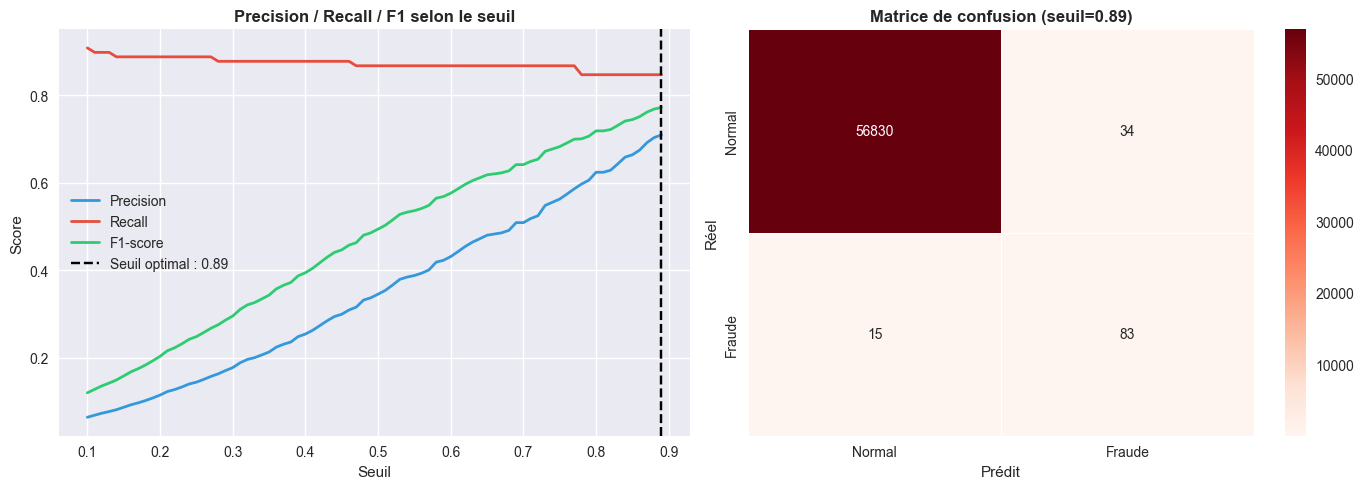


=== Rapport avec seuil optimal ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.71      0.85      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Tester différents seuils
seuils = np.arange(0.1, 0.9, 0.01)
resultats = []

for seuil in seuils:
    y_pred_seuil = (y_prob >= seuil).astype(int)
    precision = (y_pred_seuil & y_test.values).sum() / y_pred_seuil.sum() if y_pred_seuil.sum() > 0 else 0
    recall = (y_pred_seuil & y_test.values).sum() / y_test.sum()
    f1 = f1_score(y_test, y_pred_seuil, zero_division=0)
    resultats.append({'seuil': seuil, 'precision': precision, 'recall': recall, 'f1': f1})

df_seuils = pd.DataFrame(resultats)

# Seuil optimal = meilleur F1
meilleur_seuil = df_seuils.loc[df_seuils['f1'].idxmax(), 'seuil']
meilleure_f1 = df_seuils['f1'].max()

print(f"=== Seuil optimal ===")
print(f"Seuil     : {meilleur_seuil:.2f}")
print(f"Meilleur F1 : {meilleure_f1:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_seuils['seuil'], df_seuils['precision'], 
             color='#3498db', label='Precision', linewidth=2)
axes[0].plot(df_seuils['seuil'], df_seuils['recall'], 
             color='#e74c3c', label='Recall', linewidth=2)
axes[0].plot(df_seuils['seuil'], df_seuils['f1'], 
             color='#2ecc71', label='F1-score', linewidth=2)
axes[0].axvline(x=meilleur_seuil, color='black', linestyle='--', 
                label=f'Seuil optimal : {meilleur_seuil:.2f}')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].legend()

# Matrice de confusion avec le seuil optimal
y_pred_optimal = (y_prob >= meilleur_seuil).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'Matrice de confusion (seuil={meilleur_seuil:.2f})', fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()

print("\n=== Rapport avec seuil optimal ===")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraude']))

### MODÈLE AVEC scale_pos_weight

scale_pos_weight optimal : 577.3
⏳ Entraînement en cours...
✅ Modèle entraîné !

=== Métriques scale_pos_weight ===
ROC-AUC : 0.9758
AUPRC   : 0.8675

=== Rapport de classification ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



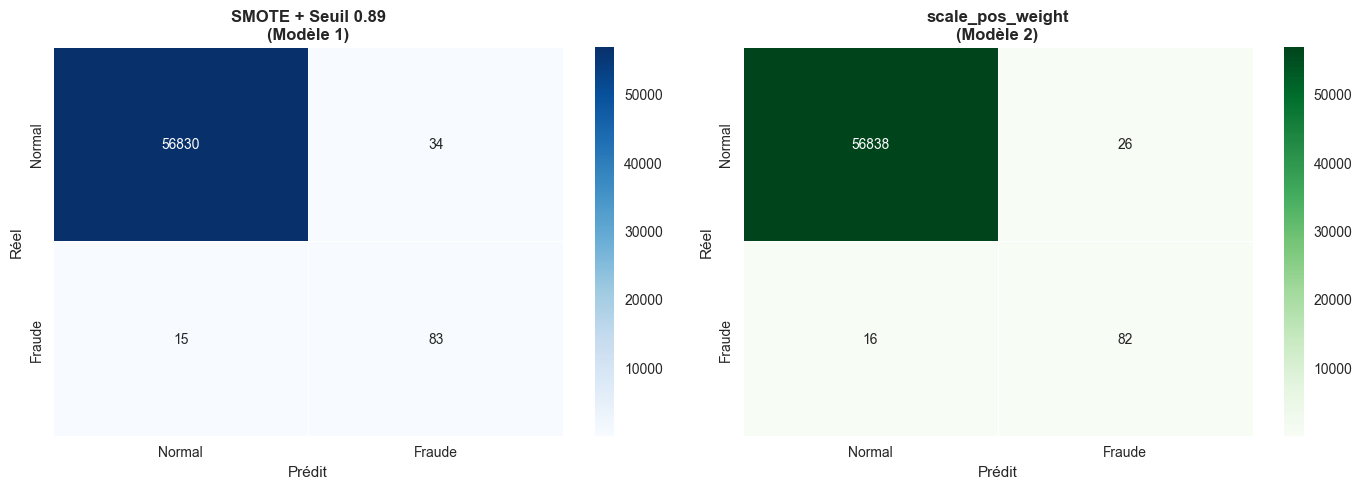

In [ ]:
# Calcul du poids optimal
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight optimal : {ratio:.1f}")

# Nouveau modèle SANS SMOTE mais avec scale_pos_weight
model_spw = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

print("⏳ Entraînement en cours...")
model_spw.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
print("✅ Modèle entraîné !")

# Prédictions
y_prob_spw = model_spw.predict_proba(X_test)[:, 1]
y_pred_spw = model_spw.predict(X_test)

# Métriques
print("\n=== Métriques scale_pos_weight ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_spw):.4f}")
print(f"AUPRC   : {average_precision_score(y_test, y_prob_spw):.4f}")
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred_spw, target_names=['Normal', 'Fraude']))

# Comparaison visuelle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice confusion SMOTE
cm_smote = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('SMOTE + Seuil 0.89\n(Modèle 1)', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Matrice confusion scale_pos_weight
cm_spw = confusion_matrix(y_test, y_pred_spw)
sns.heatmap(cm_spw, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('scale_pos_weight\n(Modèle 2)', fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()

Comparaison Modèle 1 vs Modèle 2
MétriqueModèle 1 (SMOTE + seuil 0.89)Modèle 2 (scale_pos_weight)GagnantROC-AUC0.97600.9758🟰 ÉgalAUPRC0.82700.8675✅ Modèle 2Precision Fraude0.710.76✅ Modèle 2Recall Fraude0.850.84🟰 Quasi égalF1 Fraude0.770.80✅ Modèle 2Faux Positifs3426✅ Modèle 2Fraudes détectées83/9882/98🟰 Quasi égal

### GRIDSEARCH HYPERPARAMÈTRES

In [ ]:
from sklearn.model_selection import GridSearchCV

print("⏳ GridSearch en cours... (patience ~5-10 min)")

# Grille de paramètres
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0]
}

# Modèle de base
base_model = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# GridSearch avec AUPRC comme métrique
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='average_precision',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n✅ GridSearch terminé !")
print(f"\n=== Meilleurs paramètres ===")
print(grid_search.best_params_)
print(f"\nMeilleur score CV : {grid_search.best_score_:.4f}")

# Évaluation du meilleur modèle
best_model = grid_search.best_estimator_
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

print(f"\n=== Métriques du meilleur modèle ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"AUPRC   : {average_precision_score(y_test, y_prob_best):.4f}")
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraude']))

⏳ GridSearch en cours... (patience ~5-10 min)
Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ GridSearch terminé !

=== Meilleurs paramètres ===
{'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

Meilleur score CV : 0.8468

=== Métriques du meilleur modèle ===
ROC-AUC : 0.9748
AUPRC   : 0.8737

=== Rapport de classification ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### OPTUNA (OPTIMISATION BAYÉSIENNE)

In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight': ratio,
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model_trial = xgb.XGBClassifier(**params)
    model_trial.fit(X_train, y_train, verbose=False)
    y_prob_trial = model_trial.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob_trial)

# Lancement de l'optimisation (50 essais)
print("⏳ Optuna en cours — 50 essais...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Optuna terminé !")
print(f"Meilleur AUPRC : {study.best_value:.4f}")
print(f"Meilleurs paramètres : {study.best_params}")

# Entraînement du meilleur modèle Optuna
best_params_optuna = study.best_params
best_params_optuna.update({'scale_pos_weight': ratio, 
                            'eval_metric': 'aucpr',
                            'random_state': 42, 
                            'n_jobs': -1})

model_optuna = xgb.XGBClassifier(**best_params_optuna)
model_optuna.fit(X_train, y_train, verbose=False)

y_prob_optuna = model_optuna.predict_proba(X_test)[:, 1]
y_pred_optuna = model_optuna.predict(X_test)

print(f"\n=== Métriques Optuna ===")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_optuna):.4f}")
print(f"AUPRC   : {average_precision_score(y_test, y_prob_optuna):.4f}")
print(classification_report(y_test, y_pred_optuna, target_names=['Normal', 'Fraude']))

⏳ Optuna en cours — 50 essais...


Best trial: 14. Best value: 0.884364: 100%|██████████| 50/50 [07:25<00:00,  8.91s/it]



✅ Optuna terminé !
Meilleur AUPRC : 0.8844
Meilleurs paramètres : {'n_estimators': 308, 'max_depth': 6, 'learning_rate': 0.08817889831955841, 'min_child_weight': 5, 'subsample': 0.6036652521519168, 'colsample_bytree': 0.9377922987712322, 'gamma': 0.11738252078165479, 'reg_alpha': 0.6570074886215544, 'reg_lambda': 1.473903838817213}

=== Métriques Optuna ===
ROC-AUC : 0.9799
AUPRC   : 0.8844
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.83      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### SAUVEGARDE FINALE

In [ ]:
import joblib, json, os
from sklearn.metrics import precision_score, recall_score

# Modèle final = XGBoost Optuna
# Métrique principale = AUPRC (consigne officielle dataset)

y_pred_final = model_optuna.predict(X_test)
y_prob_final = model_optuna.predict_proba(X_test)[:, 1]

print("="*50)
print("  MODÈLE FINAL — XGBoost Optuna")
print("="*50)
print(f"  Métrique principale : AUPRC (consigne dataset)")
print(f"  AUPRC   : {average_precision_score(y_test, y_prob_final):.4f} ✅")
print(f"  ROC-AUC : {roc_auc_score(y_test, y_prob_final):.4f}")
print("="*50)

# Sauvegarde
os.makedirs('../model', exist_ok=True)
joblib.dump(model_optuna, '../model/fraud_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

config = {
    'modele': 'XGBoost Optuna',
    'metrique_principale': 'AUPRC',
    'auprc': round(average_precision_score(y_test, y_prob_final), 4),
    'roc_auc': round(roc_auc_score(y_test, y_prob_final), 4),
    'seuil': 0.5,
    'features': list(X_train.columns),
    'params_optuna': model_optuna.get_params()
}

with open('../model/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("\n✅ Fichiers sauvegardés :")
print("   → model/fraud_model.pkl")
print("   → model/scaler.pkl")
print("   → model/config.json")
print("\n🚀 Notebook terminé — On attaque Streamlit !")